# Characterizing Aberrations with Optuna

<a href="https://colab.research.google.com/github/softmatterlab/DeepTrack-2.0/blob/develop/examples/tutorials/1-getting-started/DTSG127_characterizing_aberrations_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

In [ ]:
# !pip install optuna  # Uncomment if needed.

This tutorial demonstrates how to identify the aberration type and aberration coefficient of an optical device using the image of a centered particle. DeepTrack2 lets you simulate a number of different optical aberrations, which you can use to identify aberrations you may find experimental setups using various methods.

In [2]:
import random

import deeptrack as dt
import numpy as np
from matplotlib import pyplot as plt
import optuna

## 1. Defining the Aberrations

Here you gather all aberration types that DeepTrack2 can simulate into a list. 

Aberrations in DeepTrack2 are wrappers of the more general `Zernike` feature, which introduces a phase to the pupil function based on the normalized Zernike polynomials. The property `coefficient` is a multiplier for the respective poynomial in the set of Zernike polynomials.

See more details in [DTATo40_aberrations](../3-advanced-topics/DTATo40_aberrations.ipynb).

In [3]:
aberration_types = [
    dt.Piston,
    dt.VerticalTilt,
    dt.HorizontalTilt,
    dt.ObliqueAstigmatism,
    dt.Defocus,
    dt.Astigmatism,
    dt.ObliqueTrefoil,
    dt.VerticalComa,
    dt.HorizontalComa,
    dt.Trefoil,
    dt.SphericalAberration,
]

## 2. Defining the Features

Define the features needed for this example:

* `optics`: Flourescence microscope with a pixel size of 0.1 microns and a 256x256 camera.

* `particle`: Spherical particle centered in the image with 1 micrometer radius.


In [4]:
IMAGE_SIZE = 256

# Define optics.
optics = dt.Fluorescence(
    magnification=10,
    resolution=1e-6,
    wavelength=660e-9,
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

# Define scatterer.
particle = dt.Sphere(
    position=(IMAGE_SIZE // 2, IMAGE_SIZE // 2, 0),
    radius=1e-6,
    intensity=1,
)

## 3. Combining the Features

To image the particle throught the aberrated microscope, choose a random aberration from the list and modify the pupil function of the `optics` microscope with `optics.pupil`.

In [5]:
# Pick a random aberration from the list.
aberration = random.choice(aberration_types)

# Pick a random aberration strength.
aberration = aberration(coefficient=lambda: (2 * np.random.rand() - 1) * 8)

# Modify the pupil of the microscope with the aberration.
optics.pupil = aberration

Image the particle through the aberrated microscope.

Name: HorizontalComa
Coefficient: 1.7301442345449196
Radius: 1e-06
Z: 0.0


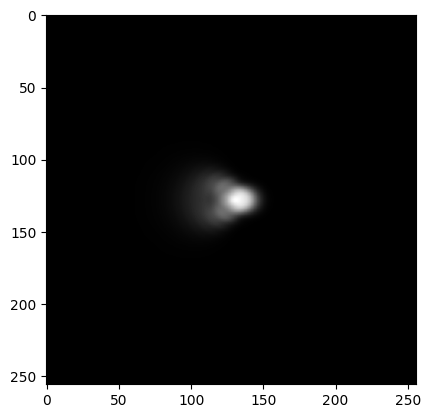

In [6]:
reference_image = optics(particle).resolve().squeeze()

plt.imshow(reference_image, cmap="gray")

print(
    f"Name: {aberration.name()}\n"
    f"Coefficient: {aberration.coefficient()}\n"
    f"Radius: {particle.radius()}\n"
    f"Z: {particle.z()}"
)

## 4. Preparing the Simulation Function for Optuna

Optuna is a hyperparameter optimization framework which lets you explore a large number of parameters with a variety of search methods.

In this tutorial, you will use the default [Tree-Structured Parzen Estimator](https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html#optuna.samplers.TPESampler) and restrict the search space to four parameters and use a simple RMSE loss function.

The search parameters are:

* Aberration category

* Aberration coefficient

* Particle radii

* Z position of the particle (along the optical axis)


In [7]:
def simulate_aberrated_image(
    aberration_candidate,  # Aberration category
    coefficient,  # Aberration coefficient
    radius,  # Particle radii
    z,  # Z position
):
    # Get the aberration type and modify the pupil.
    simulated_aberration = aberration_candidate(coefficient=coefficient)
    optics.pupil = simulated_aberration

    # Instance the particle with the trial parameters.
    particle = dt.Sphere(
        radius=radius,
        position=(IMAGE_SIZE // 2, IMAGE_SIZE // 2, z),
        intensity=1,
    )

    # Image the particle through the aberrated microscope.
    simulated_image = optics(particle).resolve().squeeze()

    return simulated_image.astype(np.float32)

## 5. Preparing the Workflow for Optuna

The following function defines the search parameters and loss function that will be used.

In [8]:
def objective(trial):
    """Optuna bjective function for aberration and particle parameters."""

    # Varies aberration type using the list defined at the start.
    aberration_name = trial.suggest_categorical(
        "aberration_name", [cls.__name__ for cls in aberration_types]
    )
    aberration_type = next(
        cls for cls in aberration_types if cls.__name__ == aberration_name
    )

    # Varies aberration strength.
    coefficient = trial.suggest_float("coefficient", -10, 10)

    # Varies particle radius.
    radius = trial.suggest_float("radius", 1e-7, 2.1e-6)

    # Varies particle z-position.
    z = trial.suggest_float("z", -1, 1)

    # Generates a simulated image with the parameters.
    simulated_image = simulate_aberrated_image(
        aberration_type,
        coefficient,
        radius,
        z,
    )

    # Pixel-wise RMSE comparison between the reference and the simulated image.
    loss = np.sqrt(np.mean(np.square(simulated_image - reference_image)))

    return loss

## 6. Running the Optimization

You are now ready to run the Optuna study, which you will do for a numebr of trials set by `n_trials`. At each iteration the loss along with the parameters will be printed which allows you to track the progress.

In [9]:
# Run Optuna study.
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=500)

print("Best Loss:", study.best_value)
print("Best parameters:", study.best_trial.params)

[I 2026-06-18 22:24:10,436] A new study created in memory with name: no-name-ba3494c1-d230-4d20-b22c-9560a2f277c7
[I 2026-06-18 22:24:10,584] Trial 0 finished with value: 0.05396707412212997 and parameters: {'aberration_name': 'ObliqueAstigmatism', 'coefficient': 2.6897167312905985, 'radius': 1.7760061614870141e-06, 'z': -0.064457224829926}. Best is trial 0 with value: 0.05396707412212997.
[I 2026-06-18 22:24:10,666] Trial 1 finished with value: 0.010852049919941337 and parameters: {'aberration_name': 'HorizontalComa', 'coefficient': -3.1563378273746245, 'radius': 1.0568372391654512e-06, 'z': 0.6374068346508261}. Best is trial 1 with value: 0.010852049919941337.
[I 2026-06-18 22:24:10,843] Trial 2 finished with value: 0.05518128522898776 and parameters: {'aberration_name': 'VerticalComa', 'coefficient': -2.3517160586848647, 'radius': 1.9217521875234188e-06, 'z': 0.38525754195199347}. Best is trial 1 with value: 0.010852049919941337.
[I 2026-06-18 22:24:10,884] Trial 3 finished with val

Best Loss: 0.0006094505564661494
Best parameters: {'aberration_name': 'HorizontalComa', 'coefficient': 1.7891030519282909, 'radius': 9.96859688596017e-07, 'z': 0.37966630503509}


## 7.  Validating the Results

With the optimization completed, extract the parameters that minimized the loss function and reproduce the image.

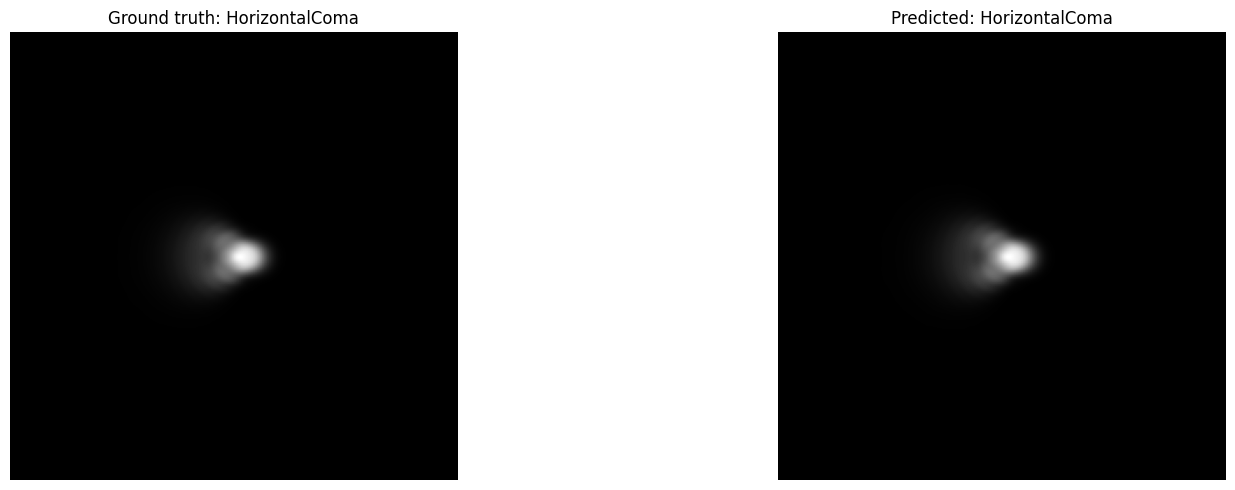

Name: HorizontalComa vs HorizontalComa
Coefficient: 1.7301442345449196 vs 1.7891030519282909
Radius: 1e-06 vs 9.96859688596017e-07
Z: 0.0 vs 0.37966630503509


In [10]:
# Get best parameters from the study.
best_params = study.best_trial.params
coeff = best_params["coefficient"]

# Reconstruct the image which had the optimal parameters.
predicted_aberration = study.best_params["aberration_name"]

# Convert string back to class.
aberration_class = next(
    cls for cls in aberration_types if cls.__name__ == predicted_aberration
)
# Create aberration instance.
predicted_aberration = aberration_class(coefficient=coeff)

optics.pupil = predicted_aberration
predicted_particle = dt.Sphere(
    radius=best_params["radius"],
    position=(IMAGE_SIZE // 2, IMAGE_SIZE // 2, best_params["z"]),
    intensity=1,
)

# Generate predicted image.
predicted_image = optics(predicted_particle).resolve().squeeze()

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
ax[0].imshow(reference_image, cmap="gray")
ax[0].set_title(f"Ground truth: {aberration.name()}")
ax[0].axis("off")

ax[1].imshow(predicted_image, cmap="gray")
ax[1].set_title(f"Predicted: {predicted_aberration.name()}")
ax[1].axis("off")

plt.tight_layout()
plt.show()

print(
    f"Name: {aberration.name()} vs {best_params['aberration_name']}\n"
    f"Coefficient: {aberration.coefficient()} vs {best_params['coefficient']}\n"
    f"Radius: {particle.radius()} vs {best_params['radius']}\n"
    f"Z: {particle.z()} vs {best_params['z']}"
)

-# TODO: Check the results, they don't seem very consistent.

-# TODO: Check the value of z. Is it in meters? why does this need to be optimized? or is it in pixels? in any case, this needs to be explained.